In [5]:
pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# 1. Generate a complex, non-linear dataset (two interlocking moons)
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# 2. Define the SVM (Using the RBF mathematical kernel)
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")

# 3. Define the MLP Neural Network (1 hidden layer with 50 artificial neurons)
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)

# 4. Train both models
svm_model.fit(X, y)
mlp_model.fit(X, y)

# 5. Check accuracy on the training data
print(f"SVM Accuracy: {svm_model.score(X, y) * 100:.1f}%")
print(f"MLP (Neural Network) Accuracy: {mlp_model.score(X, y) * 100:.1f}%")


SVM Accuracy: 96.0%
MLP (Neural Network) Accuracy: 90.5%


/Users/denistatarenko/.pyenv/versions/3.12.0/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


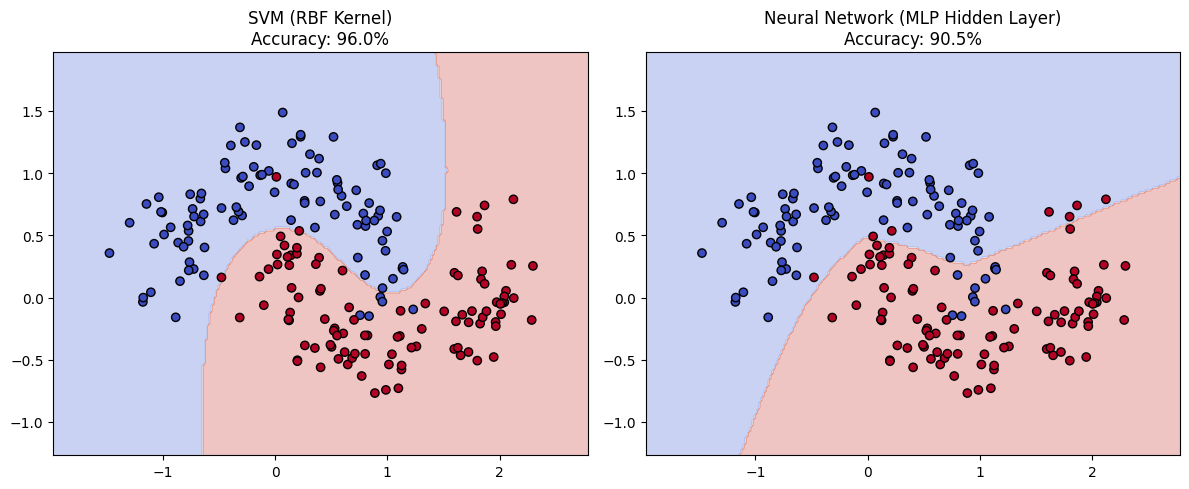

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 3. Create a grid mesh to draw the decision trajectories
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 4. Plotting the differences side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left Plot: SVM (RBF Kernel) ---
Z_svm = svm_model.predict(grid_points).reshape(xx.shape)
ax1.contourf(xx, yy, Z_svm, alpha=0.3, cmap=plt.cm.coolwarm)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
ax1.set_title(f"SVM (RBF Kernel)\nAccuracy: {svm_model.score(X, y)*100:.1f}%")

# --- Right Plot: MLP (Neural Network) ---
Z_mlp = mlp_model.predict(grid_points).reshape(xx.shape)
ax2.contourf(xx, yy, Z_mlp, alpha=0.3, cmap=plt.cm.coolwarm)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
ax2.set_title(
    f"Neural Network (MLP Hidden Layer)\nAccuracy: {mlp_model.score(X, y)*100:.1f}%"
)

plt.tight_layout()
plt.show()
